# Six-Face Test: Statistical Analysis

Use this notebook to review results from the six-face test captures made with the `dataCapture.ipynb` notebook, compare the resulting histograms directly, and compute statistics to inform calibration decisions.

## Setup

In [ ]:
import csv
from array import array
from pathlib import Path
from statistics import fmean, pstdev

import matplotlib.pyplot as plt

G = 9.80665

ACCEL_RANGE = (-15.0, 15.0)
ACCEL_BIN_WIDTH = 0.25
GYRO_RANGE = (-20.0, 20.0)
GYRO_BIN_WIDTH = 0.25

DATA_DIR = Path("./capture").resolve()


def _buildBinEdges(start: float, stop: float, width: float) -> list[float]:
    steps = int(round((stop - start) / width))
    return [start + index * width for index in range(steps + 1)]


ACCEL_BINS = _buildBinEdges(ACCEL_RANGE[0], ACCEL_RANGE[1], ACCEL_BIN_WIDTH)
GYRO_BINS = _buildBinEdges(GYRO_RANGE[0], GYRO_RANGE[1], GYRO_BIN_WIDTH)


def _plotOrientationHistogramsFromCsv(
    fileName: str, title: str, accelReferences: dict[str, float]
) -> None:
    motionData = _readMotionData(fileName)
    _plotOrientationHistograms(motionData, title, accelReferences)


def _readMotionData(fileName: str) -> dict[str, array | dict[str, array]]:
    filePath = DATA_DIR / fileName
    if not filePath.exists():
        raise FileNotFoundError(f"Capture file not found: {filePath}")

    motionData = {
        "a": {"x": array("f"), "y": array("f"), "z": array("f")},
        "w": {"roll": array("f"), "pitch": array("f"), "yaw": array("f")},
        "t": array("q"),
    }

    with open(filePath, "r", encoding="utf-8", newline="") as csvFile:
        reader = csv.DictReader(csvFile)
        expectedFieldNames = ["t_us", "ax", "ay", "az", "roll", "pitch", "yaw"]
        if reader.fieldnames != expectedFieldNames:
            raise ValueError(
                f"Unexpected CSV header in {filePath}: {reader.fieldnames}"
            )

        for row in reader:
            motionData["t"].append(int(row["t_us"]))
            motionData["a"]["x"].append(float(row["ax"]))
            motionData["a"]["y"].append(float(row["ay"]))
            motionData["a"]["z"].append(float(row["az"]))
            motionData["w"]["roll"].append(float(row["roll"]))
            motionData["w"]["pitch"].append(float(row["pitch"]))
            motionData["w"]["yaw"].append(float(row["yaw"]))

    return motionData


def _plotOrientationHistograms(
    motion_data, title: str, accel_references: dict[str, float]
) -> None:
    if len(motion_data["t"]) == 0:
        raise ValueError("No samples available for plotting.")

    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    accelPlots = [
        (
            axes[0, 0],
            motion_data["a"]["x"],
            accel_references["x"],
            "tab:blue",
            "Accel X",
            "m/s^2",
        ),
        (
            axes[1, 0],
            motion_data["a"]["y"],
            accel_references["y"],
            "tab:green",
            "Accel Y",
            "m/s^2",
        ),
        (
            axes[2, 0],
            motion_data["a"]["z"],
            accel_references["z"],
            "tab:orange",
            "Accel Z",
            "m/s^2",
        ),
    ]
    gyroPlots = [
        (axes[0, 1], motion_data["w"]["roll"], 0.0, "tab:purple", "Gyro Roll", "deg/s"),
        (axes[1, 1], motion_data["w"]["pitch"], 0.0, "tab:red", "Gyro Pitch", "deg/s"),
        (axes[2, 1], motion_data["w"]["yaw"], 0.0, "tab:brown", "Gyro Yaw", "deg/s"),
    ]

    for axis, values, reference, color, subplot_title, x_label in accelPlots:
        plotDistribution(
            axis,
            values,
            ACCEL_BINS,
            ACCEL_RANGE,
            reference,
            color,
            subplot_title,
            x_label,
        )

    for axis, values, reference, color, subplot_title, x_label in gyroPlots:
        _plotDistribution(
            axis,
            values,
            GYRO_BINS,
            GYRO_RANGE,
            reference,
            color,
            subplot_title,
            x_label,
        )

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def _plotDistribution(axis, values, bins, plot_range, reference, color, title, x_label):
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("count")
    axis.set_xlim(*plot_range)
    axis.grid(alpha=0.25)

    if len(values) == 0:
        axis.text(
            0.5, 0.5, "No samples", transform=axis.transAxes, ha="center", va="center"
        )
        return

    mean = fmean(values)
    std = pstdev(values) if len(values) > 1 else 0.0

    axis.hist(values, bins=bins, color=color, alpha=0.75, edgecolor="white")
    axis.axvline(
        reference,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"reference = {_formatReference(reference)}",
    )
    axis.axvline(
        mean,
        color="crimson",
        linestyle="-",
        linewidth=1.5,
        label=f"mean = {mean:.3f}",
    )
    axis.plot([], [], linestyle="", label=f"std = {std:.3f}")
    axis.legend(loc="upper right")


def _formatReference(reference: float) -> str:
    if abs(reference - G) < 1e-9:
        return "+g"
    if abs(reference + G) < 1e-9:
        return "-g"
    return f"{reference:.3f}"


print(f"Capture input directory: {DATA_DIR}")

Capture input directory: /home/fedep/Repos/gym-imu/signal/calibration/capture


## Histograms

### Orientation 1: +X Up

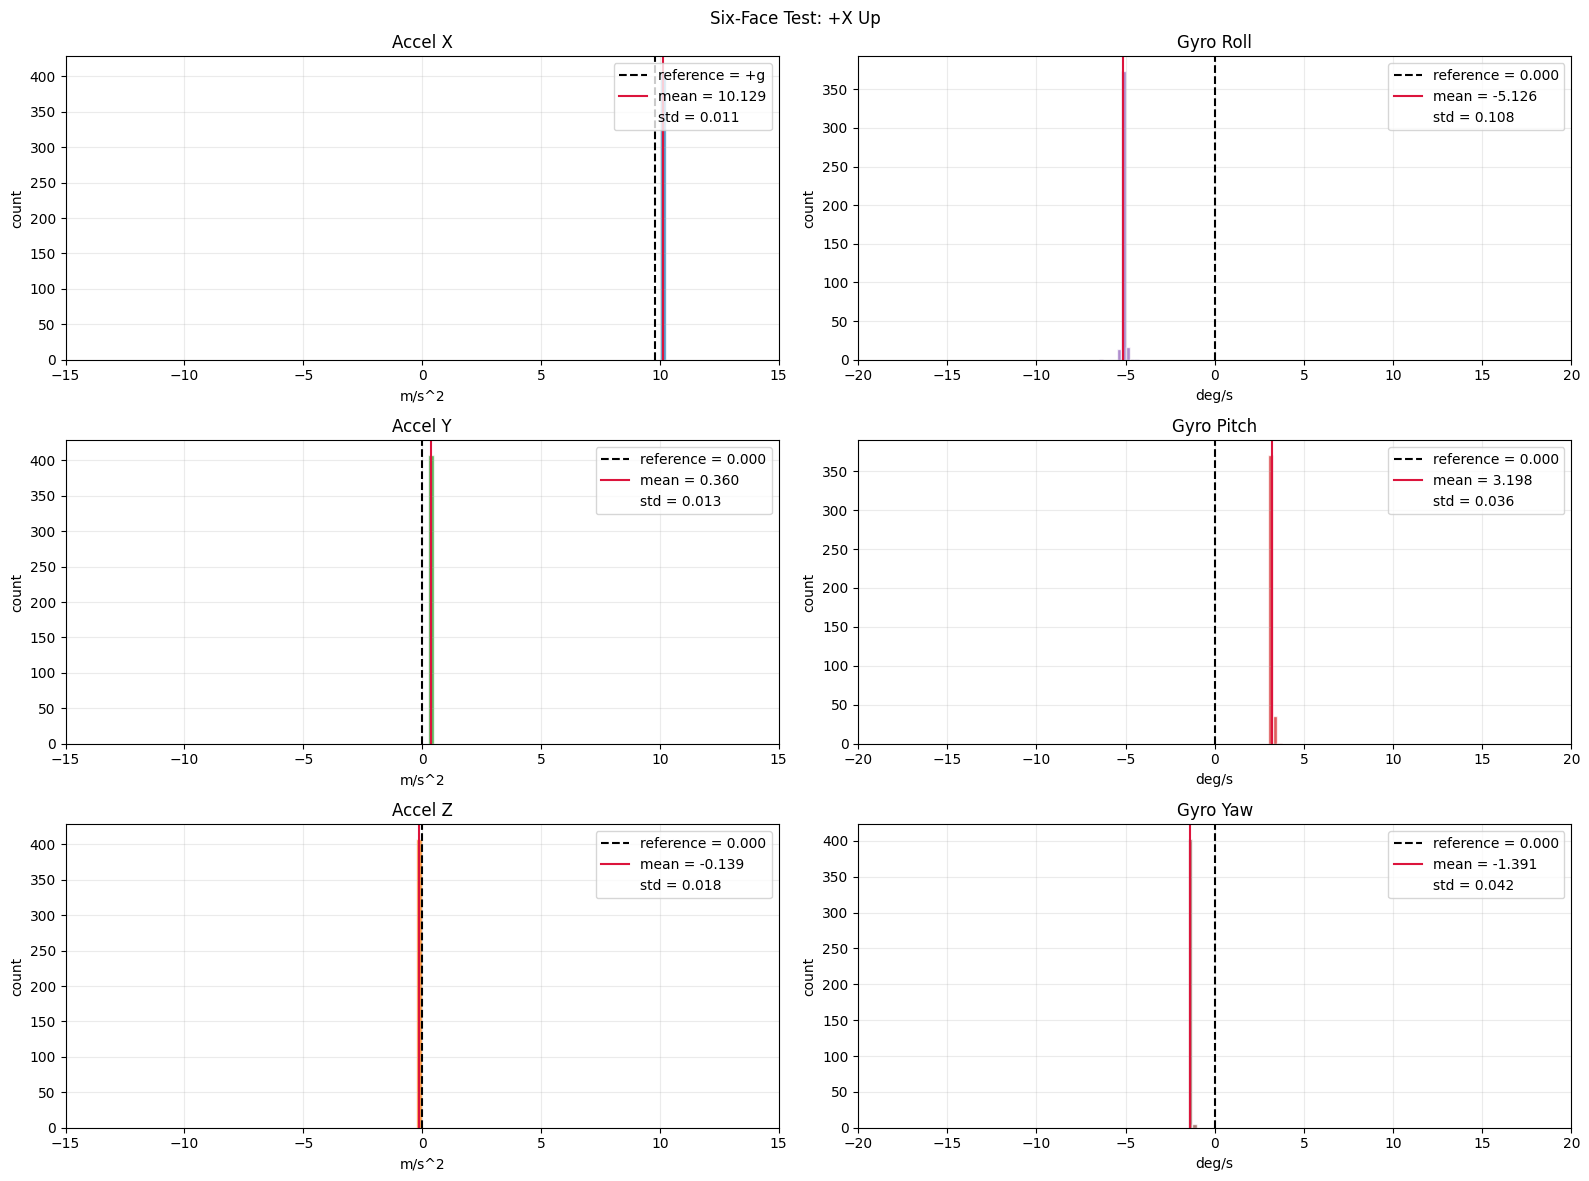

In [7]:
plotOrientationFromCsv(
    "positive-x-up.csv",
    title="Six-Face Test: +X Up",
    accelReferences={"x": G, "y": 0.0, "z": 0.0},
)

### Orientation 2: -X Up

In [ ]:
plotOrientationFromCsv(
    "negative-x-up.csv",
    title="Six-Face Test: -X Up",
    accelReferences={"x": -G, "y": 0.0, "z": 0.0},
)

### Orientation 3: +Y Up

In [ ]:
plotOrientationFromCsv(
    "positive-y-up.csv",
    title="Six-Face Test: +Y Up",
    accelReferences={"x": 0.0, "y": G, "z": 0.0},
)

### Orientation 4: -Y Up

In [ ]:
plotOrientationFromCsv(
    "negative-y-up.csv",
    title="Six-Face Test: -Y Up",
    accelReferences={"x": 0.0, "y": -G, "z": 0.0},
)

### Orientation 5: +Z Up

In [ ]:
plotOrientationFromCsv(
    "positive-z-up.csv",
    title="Six-Face Test: +Z Up",
    accelReferences={"x": 0.0, "y": 0.0, "z": G},
)

### Orientation 6: -Z Up

In [ ]:
plotOrientationFromCsv(
    "negative-z-up.csv",
    title="Six-Face Test: -Z Up",
    accelReferences={"x": 0.0, "y": 0.0, "z": -G},
)